In [141]:
%matplotlib inline #jupyter魔法指令
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l #一些库，因为主要是有d2l，其实torch就行

In [142]:
#这里我是直接把在kaggle上的数据文件解压在同一个文件夹下面，放在了data里面，也可以用书上的方法先自定义两个函数balabalabala
train_data=pd.read_csv('data/train.csv')
test_data=pd.read_csv('data/test.csv')

In [143]:
#看看长什么样
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [144]:
#看看长什么样
print(train_data.iloc[0:4,[0,1,2,3,-3,-2,-1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [145]:
#把id这一列去掉
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

In [146]:
#清洗填补归一化数据
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
lambda x: (x - x.mean()) / (x.std()))
# 在标准化数据之后，所有均值消失，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)
all_features = pd.get_dummies(all_features, dummy_na=True)
all_features.shape              #这里不知道为什么特征数少一个，书上是331.后面也可能是因为这个问题要在教材的基础上加一句

(2919, 330)

In [147]:
df = all_features.copy()         #就是这一句（    有一个数据没转换过来似乎，，，我也想知道为什么
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')
    df[col] = df[col].map({v:i for i,v in enumerate(df[col].unique())})
df = df.fillna(df.mean()).astype(np.float32)
n_train = train_data.shape[0]
train_features = torch.tensor(df[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(df[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.iloc[:,-1].fillna(0).values.reshape(-1,1), dtype=torch.float32)


In [148]:
loss=nn.MSELoss() #损失函数
in_features=train_features.shape[1]
def get_net():    #就一层线性网络就能到这种准确率，，，
    net=nn.Sequential(nn.Linear(in_features,1))
    return net
def log_rmes(net,features,labels):   #取对数来看误差
    clipped_preds=torch.clamp(net(features),1,float('inf'))
    rmse=torch.sqrt(loss(torch.log(clipped_preds),torch.log(labels)))
    return rmse.item()
def train(net,train_features,train_labels,test_features,test_labels,num_epochs,learning_rate,weight_decay,batch_size): #训练
    train_ls,test_ls=[],[]
    train_iter=d2l.load_array((train_features,train_labels),batch_size)
    optimizer = torch.optim.Adam(net.parameters(),lr=learning_rate,weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for x,y in train_iter:
            optimizer.zero_grad()
            l=loss(net(x),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmes(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmes(net,test_features,test_labels))
    return train_ls,test_ls

In [149]:
def get_k_fold_data(k, i, x, y):    #k折交叉验证
    assert k > 1
    fold_size = x.shape[0] // k
    x_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        x_part, y_part = x[idx, :], y[idx]
        if j == i:
            x_valid, y_valid = x_part, y_part
        elif x_train is None:
            x_train, y_train = x_part, y_part
        else:
            x_train = torch.cat([x_train, x_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return x_train,y_train,x_valid,y_valid

In [150]:
def k_fold(k, x_train, y_train, num_epochs, learning_rate, weight_decay,batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, x_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
                f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

折1，训练log rmse0.170756, 验证log rmse0.157211
折2，训练log rmse0.162367, 验证log rmse0.189550
折3，训练log rmse0.163907, 验证log rmse0.168517
折4，训练log rmse0.167878, 验证log rmse0.154557
折5，训练log rmse0.162565, 验证log rmse0.182313
5：平均训练log rmse0.165495,平均验证log rmse0.170430


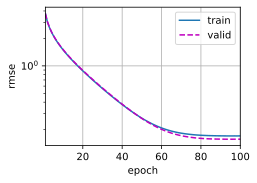

In [151]:
k,num_epochs,lr,weight_decay,batch_size=5,100,5,0,64       #学习率为5有说法的
train_l,valid_l=k_fold(k,train_features,train_labels,num_epochs,lr,weight_decay,batch_size)     #美美训练
print(f'{k}：平均训练log rmse{float(train_l):f},'
      f'平均验证log rmse{float(valid_l):f}')

In [152]:
def train_and_pred(train_features, test_features, train_labels, test_data,       #验证测试数据以及生成最后提交的文件
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162501


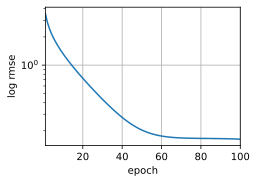

In [153]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)